In [2]:
import pandas as pd


In [3]:
pwd

'/Users/brylew/github/brave-childcare-godot'

In [4]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Define core paths.
output_dir = Path('outputs/')
input_dir = Path('inputs/')
plot_dir = Path('analysis/plots/')
plot_dir.mkdir(parents=True, exist_ok=True)

stats_path = output_dir / 'output_childcare_stats.json'

def _normalize_run_id(raw):
    text = str(raw).strip()
    if text.startswith('id-'):
        return text
    if text.isdigit():
        return f"id-{int(text):04d}"
    return text

def _latest_run_id_from_stats(path: Path) -> str:
    latest = None
    if path.exists():
        with open(path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    row = json.loads(line)
                except json.JSONDecodeError:
                    continue
                if row.get('event') == 'run_summary' and row.get('run_id') is not None:
                    latest = _normalize_run_id(row['run_id'])
    if latest is None:
        raise FileNotFoundError(f"Could not determine latest run_id from: {path}")
    return latest

run_id = _latest_run_id_from_stats(stats_path)
exposure_file = output_dir / f'output_childcare_people_movement_exposure_{run_id}.json'
person_file = input_dir / 'persons_childcare_pop.json'

output_prefix = f'run_{run_id}_'

print(f"Stats file: {stats_path}")
print(f"Selected latest run_id: {run_id}")
print(f"Looking for exposure file at: {exposure_file}")
print(f"Looking for person file at: {person_file}")
print(f"Using figure name prefix: {output_prefix}")
print(f"Files exist: stats={stats_path.exists()}, exposure={exposure_file.exists()}, person={person_file.exists()}")

Stats file: outputs/output_childcare_stats.json
Selected latest run_id: id-0149
Looking for exposure file at: outputs/output_childcare_people_movement_exposure_id-0149.json
Looking for person file at: inputs/persons_childcare_pop.json
Using figure name prefix: run_id-0149_
Files exist: stats=True, exposure=True, person=True


In [5]:
# Load exposure data from JSON file
exposure_rows = []
if exposure_file.exists():
    with open(exposure_file, 'r') as f:
        for line in f:
            if line.strip():
                row = json.loads(line)
                exposure_rows.append(row)

exposure_df = pd.DataFrame(exposure_rows)
print(f"Loaded {len(exposure_df)} exposure records")
print(f"Columns: {list(exposure_df.columns)}")
print(f"\nFirst few rows:")
print(exposure_df.head())

Loaded 801 exposure records
Columns: ['event', 'player_name', 'run_id', 'run_number', 'timestamp', 'cumulative_viral_exposure', 'pid', 'sample_count', 'time']

First few rows:
             event player_name run_id  run_number            timestamp  \
0    session_start       Bryan   0149       149.0  2026-04-29T19:40:16   
1  person_exposure         NaN    NaN         NaN                  NaN   
2  person_exposure         NaN    NaN         NaN                  NaN   
3  person_exposure         NaN    NaN         NaN                  NaN   
4  person_exposure         NaN    NaN         NaN                  NaN   

   cumulative_viral_exposure  pid  sample_count     time  
0                        NaN  NaN           NaN      NaN  
1                        0.0  101           0.0  24251.2  
2                        0.0  102           0.0  24251.2  
3                        0.0  103           0.0  24251.2  
4                        0.0  104           0.0  24251.2  


In [6]:
# Load person data to get role/type information
person_data = []
if person_file.exists():
    with open(person_file, 'r') as f:
        person_data = json.load(f)

# Create a mapping from pid to role
pid_to_role = {}
for person in person_data:
    pid_to_role[str(person.get('pid', ''))] = person.get('role', 'unknown')

print(f"Loaded {len(pid_to_role)} persons")
print(f"Roles found: {set(pid_to_role.values())}")

# Add role column to exposure dataframe
if exposure_df is not None and len(exposure_df) > 0:
    exposure_df['role'] = exposure_df['pid'].map(pid_to_role)
    print(f"\nExposure data with roles:")
    print(exposure_df[['pid', 'role', 'cumulative_viral_exposure', 'sample_count']].head(10))

Loaded 50 persons
Roles found: {'floaters', 'infants', 'providers', 'preschoolers', 'older toddlers', 'younger toddlers'}

Exposure data with roles:
   pid              role  cumulative_viral_exposure  sample_count
0  NaN               NaN                        NaN           NaN
1  101           infants                        0.0           0.0
2  102           infants                        0.0           0.0
3  103           infants                        0.0           0.0
4  104           infants                        0.0           0.0
5  105           infants                        0.0           0.0
6  106           infants                        0.0           0.0
7  201  younger toddlers                        0.0           0.0
8  202  younger toddlers                        0.0           0.0
9  203  younger toddlers                        0.0           0.0


In [7]:
final_exposure['role'].sort_values().unique()

NameError: name 'final_exposure' is not defined

In [8]:
# Get final cumulative exposure per person (last value for each pid)
final_exposure = exposure_df.sort_values('time').drop_duplicates('pid', keep='last')
final_exposure = final_exposure.sort_values('cumulative_viral_exposure', ascending=False)

print(f"Final exposure statistics by role:")
for role in final_exposure['role'].sort_values().unique():
    role_data = final_exposure[final_exposure['role'] == role]
    print(f"\n{role}:")
    print(f"  Count: {len(role_data)}")
    print(f"  Mean exposure: {role_data['cumulative_viral_exposure'].mean():.2f}")
    print(f"  Max exposure: {role_data['cumulative_viral_exposure'].max():.2f}")
    print(f"  Min exposure: {role_data['cumulative_viral_exposure'].min():.2f}")

Final exposure statistics by role:

floaters:
  Count: 2
  Mean exposure: 35432.94
  Max exposure: 46557.58
  Min exposure: 24308.31

infants:
  Count: 6
  Mean exposure: 61388.31
  Max exposure: 89416.72
  Min exposure: 35718.86

older toddlers:
  Count: 10
  Mean exposure: 60828.14
  Max exposure: 82750.37
  Min exposure: 24.31

preschoolers:
  Count: 16
  Mean exposure: 91337.17
  Max exposure: 169020.37
  Min exposure: 35583.74

providers:
  Count: 8
  Mean exposure: 43654.97
  Max exposure: 76632.89
  Min exposure: 17271.25

younger toddlers:
  Count: 8
  Mean exposure: 95772.99
  Max exposure: 129262.42
  Min exposure: 52684.10

nan:
  Count: 0
  Mean exposure: nan
  Max exposure: nan
  Min exposure: nan


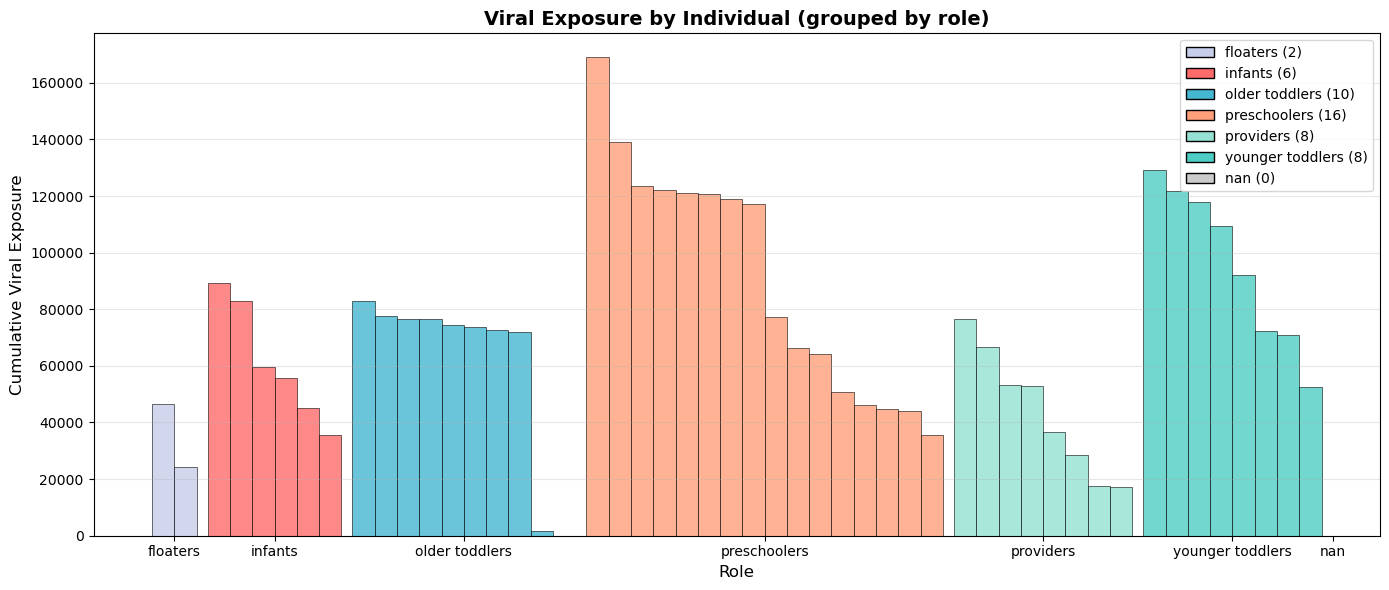


Total individuals plotted: 51
Saved: analysis/plots/run_id-0149_01_exposure_by_individual.png


In [9]:
# Create color palette for roles
role_colors = {
    'infants': '#FF6B6B',
    'younger toddlers': '#4ECDC4',
    'older toddlers': '#45B7D1',
    'preschoolers': '#FFA07A',
    'providers': '#95E1D3',
    'floaters': '#C7CEEA',
    'unknown': '#CCCCCC'
}

# Get unique roles and their counts
roles = final_exposure['role'].sort_values().unique()
role_counts = {role: len(final_exposure[final_exposure['role'] == role]) for role in roles}

# Plot cumulative exposure by PID with color by role - grouped by role
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(14, 6))

x_pos = 0
x_tick_positions = []
x_tick_labels = []
bar_width = 0.6

# Plot each role's people as a group
for role in roles:
    role_data = final_exposure[final_exposure['role'] == role]
    color = role_colors.get(role, '#CCCCCC')
    num_in_role = len(role_data)
    
    # Store the starting position for this role's group
    role_start = x_pos
    
    # Plot each person in this role as a side-by-side bar
    for idx, (_, row) in enumerate(role_data.iterrows()):
        ax.bar(x_pos, row['cumulative_viral_exposure'], 
               width=bar_width,
               color=color,
               alpha=0.8,
               edgecolor='black',
               linewidth=0.5)
        x_pos += bar_width
    
    # Calculate the center of this role's group for the tick label
    role_center = role_start + (num_in_role - 1) * bar_width / 2
    x_tick_positions.append(role_center)
    x_tick_labels.append(role)
    
    # Add space between role groups
    x_pos += 0.3

ax.set_xticks(x_tick_positions)
ax.set_xticklabels(x_tick_labels)
ax.set_xlabel('Role', fontsize=12)
ax.set_ylabel('Cumulative Viral Exposure', fontsize=12)
ax.set_title('Viral Exposure by Individual (grouped by role)', fontsize=14, fontweight='bold')

# Create legend with role names and counts
legend_elements = [Patch(facecolor=role_colors.get(role, '#CCCCCC'), 
                         edgecolor='black', 
                         label=f"{role} ({role_counts[role]})")
                   for role in roles]
ax.legend(handles=legend_elements, loc='upper right', frameon=True)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(plot_dir / f'{output_prefix}01_exposure_by_individual.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTotal individuals plotted: {len(final_exposure)}")
print(f"Saved: {plot_dir / f'{output_prefix}01_exposure_by_individual.png'}")

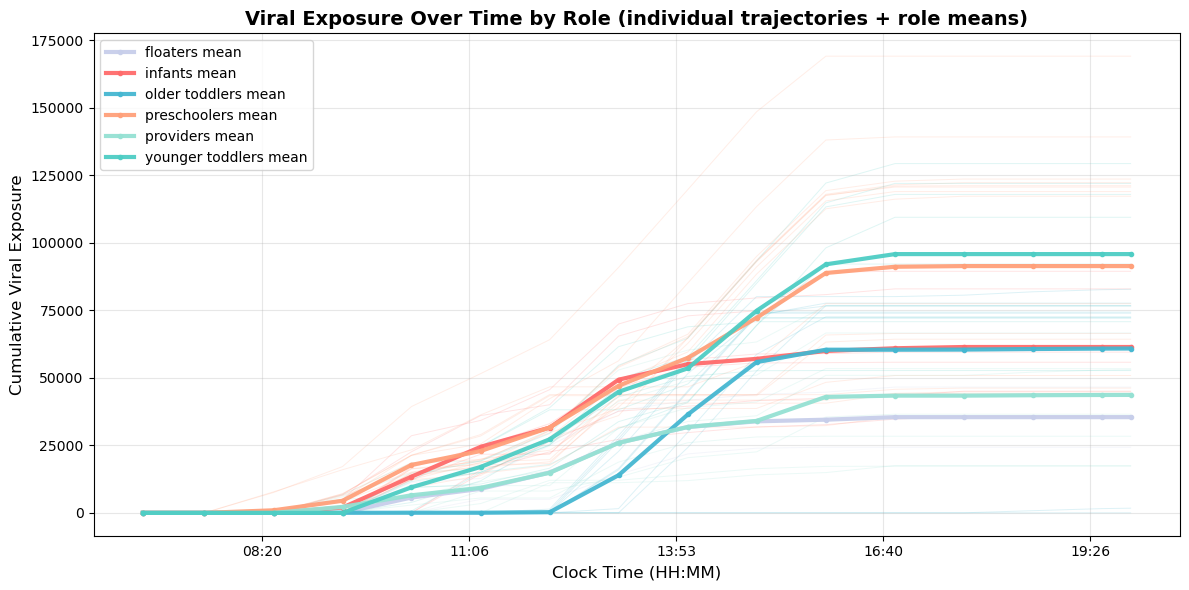

Saved: analysis/plots/run_id-0149_02_exposure_over_time.png


In [10]:
# Plot cumulative exposure over time with individual trajectories + role means
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(12, 6))

for role in sorted(exposure_df['role'].dropna().unique()):
    role_data = exposure_df[exposure_df['role'] == role].sort_values(['pid', 'time'])
    color = role_colors.get(role, '#CCCCCC')

    # Individual trajectories: thin and transparent so the mean remains dominant.
    for pid, pid_data in role_data.groupby('pid'):
        ax.plot(
            pid_data['time'],
            pid_data['cumulative_viral_exposure'],
            color=color,
            linewidth=0.7,
            alpha=0.18,
            zorder=1
        )

    # Role mean trajectory: thicker and more opaque for emphasis.
    time_avg = role_data.groupby('time')['cumulative_viral_exposure'].mean()
    ax.plot(
        time_avg.index,
        time_avg.values,
        label=f"{role} mean",
        linewidth=3.0,
        color=color,
        alpha=0.95,
        marker='o',
        markersize=3,
        zorder=3
    )

# Format x-axis seconds as HH:MM clock time.
def _seconds_to_clock(x, _pos):
    total_seconds = int(round(x))
    hours = (total_seconds // 3600) % 24
    minutes = (total_seconds % 3600) // 60
    return f"{hours:02d}:{minutes:02d}"

ax.xaxis.set_major_formatter(FuncFormatter(_seconds_to_clock))

ax.set_xlabel('Clock Time (HH:MM)', fontsize=12)
ax.set_ylabel('Cumulative Viral Exposure', fontsize=12)
ax.set_title('Viral Exposure Over Time by Role (individual trajectories + role means)', fontsize=14, fontweight='bold')
ax.legend(frameon=True, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(plot_dir / f'{output_prefix}02_exposure_over_time.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {plot_dir / f'{output_prefix}02_exposure_over_time.png'}")

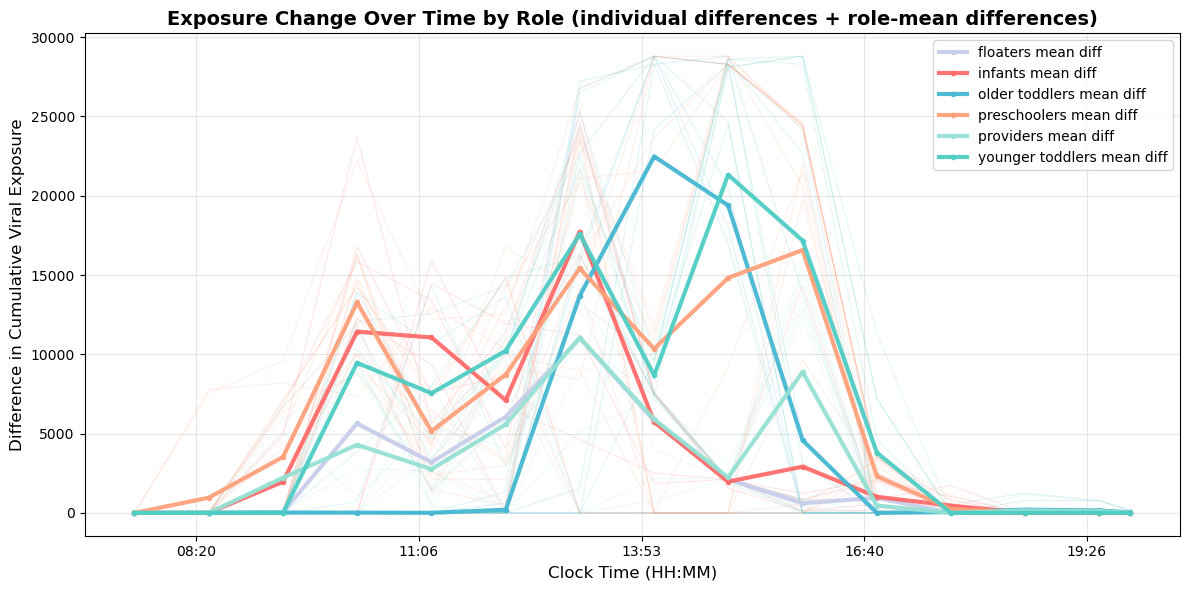

Saved: analysis/plots/run_id-0149_03_exposure_differences.png


In [11]:
# Plot first differences in cumulative exposure over time
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(12, 6))

for role in sorted(exposure_df['role'].dropna().unique()):
    role_data = exposure_df[exposure_df['role'] == role].sort_values(['pid', 'time']).copy()
    color = role_colors.get(role, '#CCCCCC')

    # Per-person first differences in cumulative exposure.
    role_data['delta_exposure'] = role_data.groupby('pid')['cumulative_viral_exposure'].diff()

    # Individual trajectories: thin and transparent.
    for pid, pid_data in role_data.groupby('pid'):
        pid_diff = pid_data.dropna(subset=['delta_exposure'])
        ax.plot(
            pid_diff['time'],
            pid_diff['delta_exposure'],
            color=color,
            linewidth=0.7,
            alpha=0.18,
            zorder=1
        )

    # Role mean of first differences: thicker and more opaque.
    role_mean_diff = role_data.groupby('time')['delta_exposure'].mean().dropna()
    ax.plot(
        role_mean_diff.index,
        role_mean_diff.values,
        label=f"{role} mean diff",
        linewidth=3.0,
        color=color,
        alpha=0.95,
        marker='o',
        markersize=3,
        zorder=3
    )

# Format x-axis seconds as HH:MM clock time.
def _seconds_to_clock(x, _pos):
    total_seconds = int(round(x))
    hours = (total_seconds // 3600) % 24
    minutes = (total_seconds % 3600) // 60
    return f"{hours:02d}:{minutes:02d}"

ax.xaxis.set_major_formatter(FuncFormatter(_seconds_to_clock))

ax.set_xlabel('Clock Time (HH:MM)', fontsize=12)
ax.set_ylabel('Difference in Cumulative Viral Exposure', fontsize=12)
ax.set_title('Exposure Change Over Time by Role (individual differences + role-mean differences)', fontsize=14, fontweight='bold')
ax.legend(frameon=True, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(plot_dir / f'{output_prefix}03_exposure_differences.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {plot_dir / f'{output_prefix}03_exposure_differences.png'}")

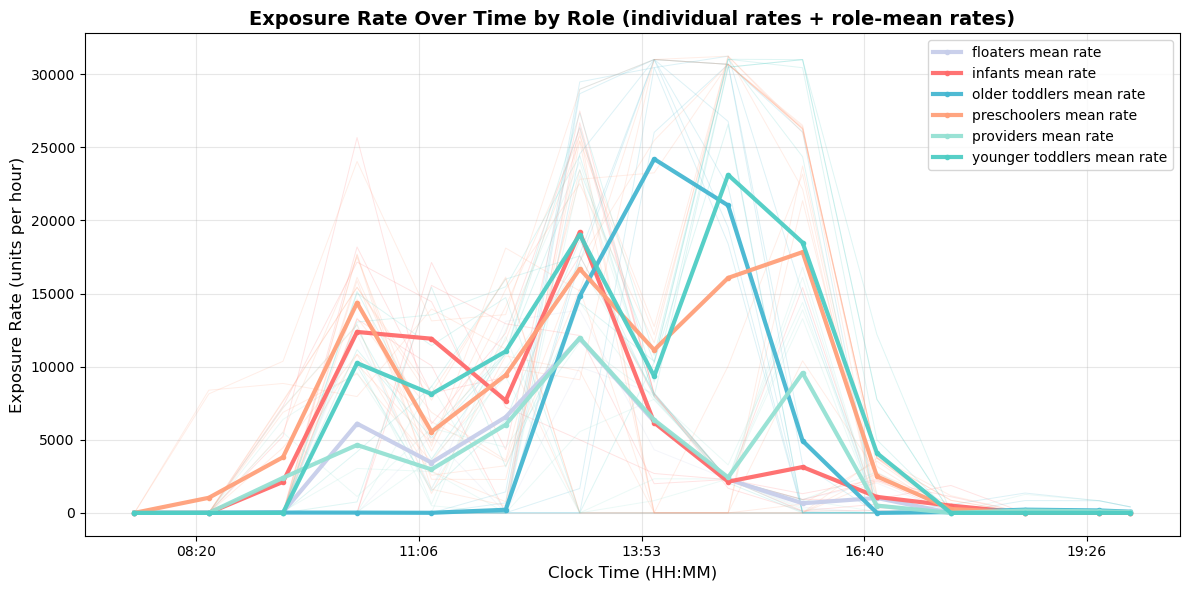

Saved: analysis/plots/run_id-0149_04_exposure_rate.png


In [12]:
# Plot exposure change rate over time (delta exposure per hour)
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(12, 6))

for role in sorted(exposure_df['role'].dropna().unique()):
    role_data = exposure_df[exposure_df['role'] == role].sort_values(['pid', 'time']).copy()
    color = role_colors.get(role, '#CCCCCC')

    # Compute per-person differences and elapsed time.
    role_data['delta_exposure'] = role_data.groupby('pid')['cumulative_viral_exposure'].diff()
    role_data['delta_time_s'] = role_data.groupby('pid')['time'].diff()

    # Rate in exposure units per hour.
    role_data['exposure_rate_per_hour'] = np.where(
        role_data['delta_time_s'] > 0,
        role_data['delta_exposure'] * 3600.0 / role_data['delta_time_s'],
        np.nan
    )

    # Individual rates: thin and transparent.
    for pid, pid_data in role_data.groupby('pid'):
        pid_rate = pid_data.dropna(subset=['exposure_rate_per_hour'])
        ax.plot(
            pid_rate['time'],
            pid_rate['exposure_rate_per_hour'],
            color=color,
            linewidth=0.7,
            alpha=0.18,
            zorder=1
        )

    # Role-mean rate: thicker and more opaque.
    role_mean_rate = role_data.groupby('time')['exposure_rate_per_hour'].mean().dropna()
    ax.plot(
        role_mean_rate.index,
        role_mean_rate.values,
        label=f"{role} mean rate",
        linewidth=3.0,
        color=color,
        alpha=0.95,
        marker='o',
        markersize=3,
        zorder=3
    )

# Format x-axis seconds as HH:MM clock time.
def _seconds_to_clock(x, _pos):
    total_seconds = int(round(x))
    hours = (total_seconds // 3600) % 24
    minutes = (total_seconds % 3600) // 60
    return f"{hours:02d}:{minutes:02d}"

ax.xaxis.set_major_formatter(FuncFormatter(_seconds_to_clock))

ax.set_xlabel('Clock Time (HH:MM)', fontsize=12)
ax.set_ylabel('Exposure Rate (units per hour)', fontsize=12)
ax.set_title('Exposure Rate Over Time by Role (individual rates + role-mean rates)', fontsize=14, fontweight='bold')
ax.legend(frameon=True, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(plot_dir / f'{output_prefix}04_exposure_rate.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {plot_dir / f'{output_prefix}04_exposure_rate.png'}")

Looking for room file at: outputs/output_childcare_rooms_id-0149.json


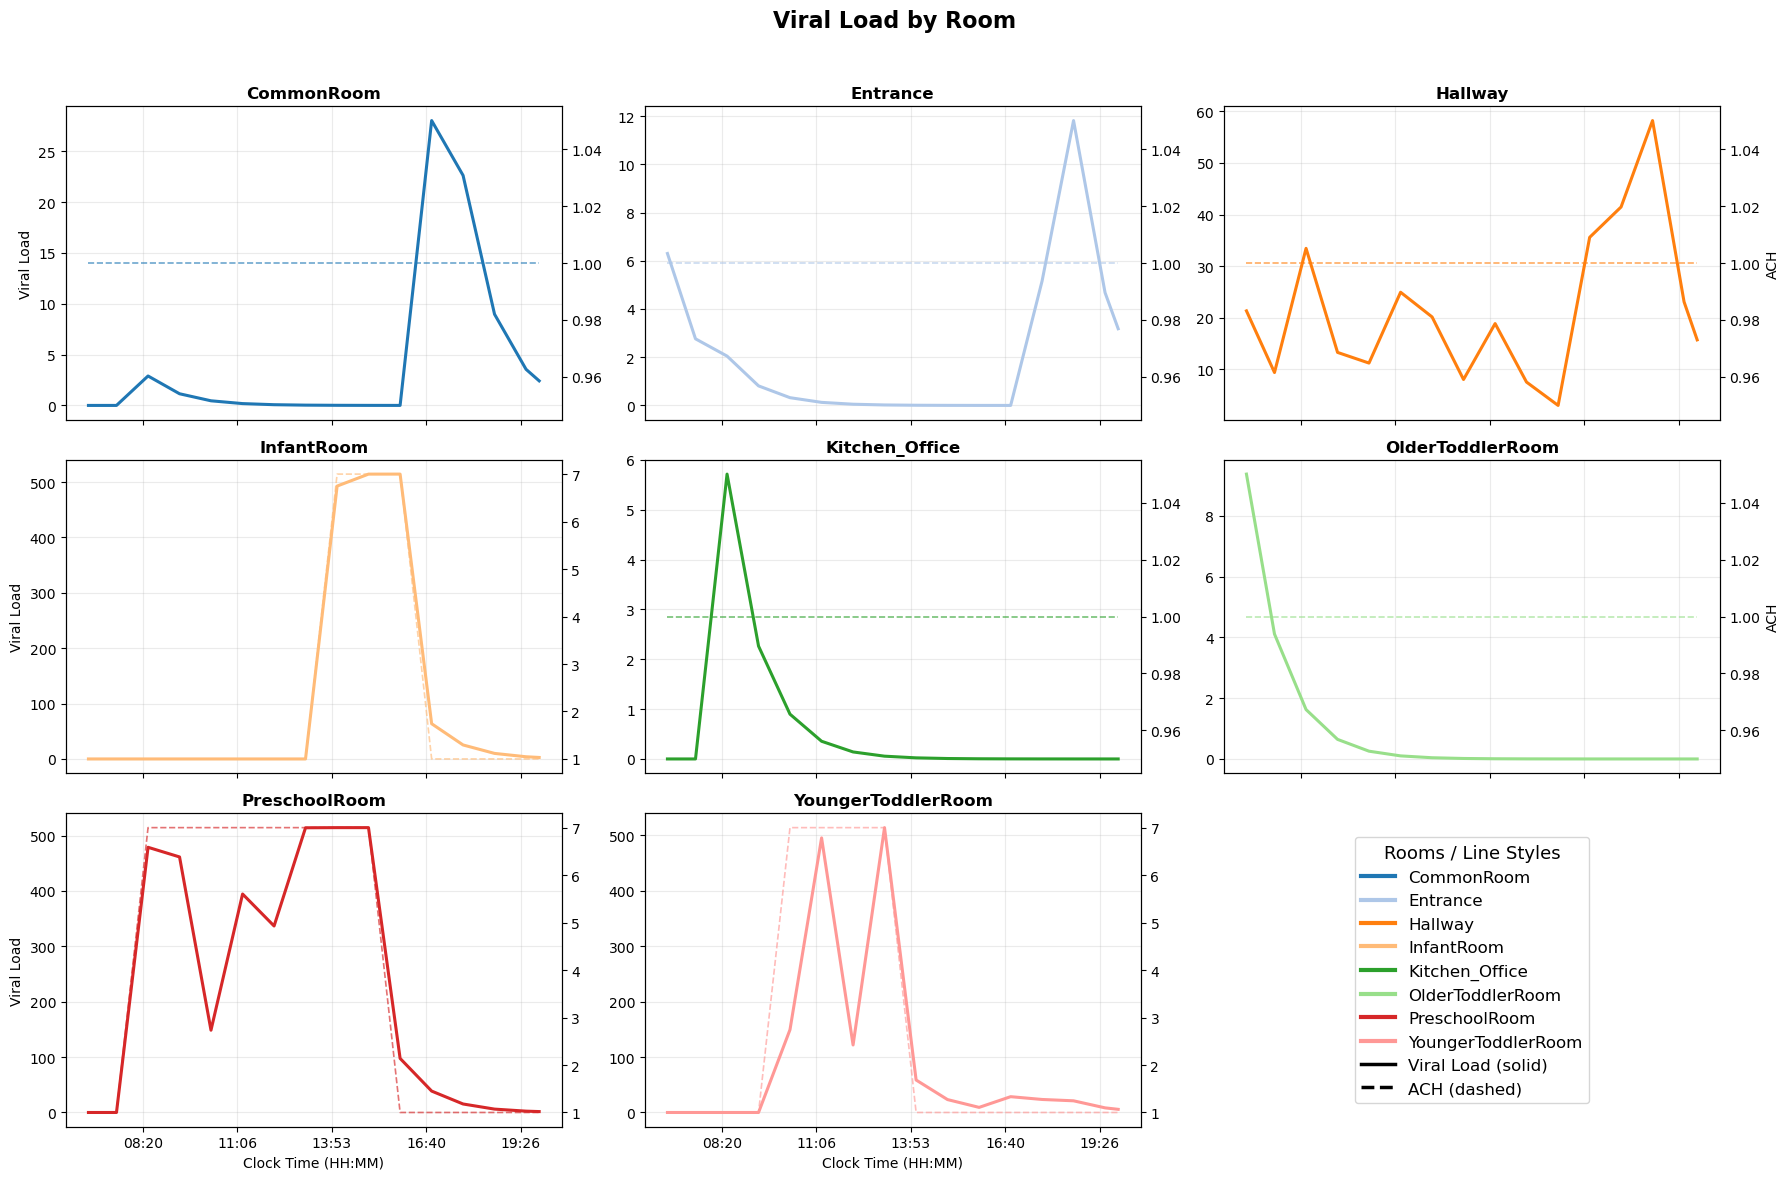

Loaded 128 room_state records across 8 rooms
Saved: analysis/plots/run_id-0149_05_room_trends.png


In [13]:
# Plot room trajectories as a 3x3 grid (8 rooms + legend panel)
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

room_file = output_dir / f'output_childcare_rooms_{run_id}.json'
print(f"Looking for room file at: {room_file}")

room_rows = []
if room_file.exists():
    with open(room_file, 'r') as f:
        for line in f:
            if line.strip():
                room_rows.append(json.loads(line))

room_df = pd.DataFrame(room_rows)
if room_df.empty:
    print('No room data loaded. Check room file path.')
else:
    if 'event' in room_df.columns:
        room_df = room_df[room_df['event'] == 'room_state'].copy()

    room_df['time'] = pd.to_numeric(room_df['time'], errors='coerce')
    room_df['viral_load'] = pd.to_numeric(room_df['viral_load'], errors='coerce')
    room_df['ach'] = pd.to_numeric(room_df['ach'], errors='coerce')
    room_df = room_df.dropna(subset=['time', 'viral_load', 'ach']).sort_values(['room_name', 'time'])

    room_names = sorted(room_df['room_name'].dropna().unique())
    cmap = plt.get_cmap('tab20')
    room_color_map = {name: cmap(i % 20) for i, name in enumerate(room_names)}

    fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharex=True)
    axes_flat = axes.flatten()

    # Format x-axis seconds as HH:MM clock time.
    def _seconds_to_clock(x, _pos):
        total_seconds = int(round(x))
        hours = (total_seconds // 3600) % 24
        minutes = (total_seconds % 3600) // 60
        return f"{hours:02d}:{minutes:02d}"

    # Plot each room in its own subplot (first 8 slots).
    for i, room_name in enumerate(room_names[:8]):
        ax = axes_flat[i]
        ax2 = ax.twinx()
        room_data = room_df[room_df['room_name'] == room_name]
        color = room_color_map[room_name]

        ax.plot(
            room_data['time'],
            room_data['viral_load'],
            color=color,
            linewidth=2.2,
            alpha=1.0,
            linestyle='-',
            zorder=3
        )

        ax2.plot(
            room_data['time'],
            room_data['ach'],
            color=color,
            linewidth=1.2,
            alpha=0.65,
            linestyle='--',
            zorder=3
        )

        ax.set_title(room_name, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.25)
        ax.xaxis.set_major_formatter(FuncFormatter(_seconds_to_clock))

        # Left axis label only on first column for readability.
        if i % 3 == 0:
            ax.set_ylabel('Viral Load')

        # Right axis label only on last column for readability.
        if i % 3 == 2:
            ax2.set_ylabel('ACH')

    # Use final subplot (9th) as legend/key panel.
    legend_ax = axes_flat[8]
    legend_ax.axis('off')

    room_handles = [
        Line2D([0], [0], color=room_color_map[name], lw=3.0, label=name)
        for name in room_names[:8]
    ]
    style_handles = [
        Line2D([0], [0], color='black', lw=2.5, ls='-', label='Viral Load (solid)'),
        Line2D([0], [0], color='black', lw=2.5, ls='--', label='ACH (dashed)')
    ]

    legend_ax.legend(
        handles=room_handles + style_handles,
        loc='center',
        frameon=True,
        title='Rooms / Line Styles',
        fontsize=12,
        title_fontsize=13
    )

    # Bottom row x-labels.
    for idx in [6, 7]:
        axes_flat[idx].set_xlabel('Clock Time (HH:MM)')

    plt.suptitle('Viral Load by Room', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.96])
    plt.savefig(plot_dir / f'{output_prefix}05_room_trends.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Loaded {len(room_df)} room_state records across {len(room_names)} rooms")
    print(f"Saved: {plot_dir / f'{output_prefix}05_room_trends.png'}")

In [14]:
# Summary table of final exposures
summary_table = final_exposure[['pid', 'role', 'cumulative_viral_exposure', 'sample_count']].copy()
summary_table = summary_table.rename(columns={
    'pid': 'Person ID',
    'role': 'Role',
    'cumulative_viral_exposure': 'Cumulative Exposure',
    'sample_count': 'Samples'
})
summary_table['Cumulative Exposure'] = summary_table['Cumulative Exposure'].round(2)

print("Top 20 individuals by cumulative viral exposure:")
print(summary_table.head(20).to_string(index=False))

Top 20 individuals by cumulative viral exposure:
Person ID             Role  Cumulative Exposure  Samples
      415     preschoolers            169020.37    363.0
      412     preschoolers            139135.51    357.0
      203 younger toddlers            129262.42    275.0
      413     preschoolers            123546.97    351.0
      416     preschoolers            122192.80    350.0
      206 younger toddlers            121931.13    324.0
      411     preschoolers            121082.86    357.0
      410     preschoolers            120577.91    354.0
      402     preschoolers            118910.88    353.0
      205 younger toddlers            117862.71    272.0
      414     preschoolers            117189.57    352.0
      207 younger toddlers            109393.85    265.0
      208 younger toddlers             92090.00    319.0
      102          infants             89416.72    379.0
      105          infants             82901.32    372.0
      301   older toddlers             